# Summary Notebook Comparing Supervised, Unsupervised, and Deep Learning Model Performance

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style = "whitegrid")

import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)
import sys
sys.path.append('../')

from src.utils import plot_confusion, plot_precision_recall

## Load Test Set and Artifacts

In [2]:
# Load external test set
df_test = pd.read_csv("../data/processed/KDDTest+_processed.csv")
# load saved feature list and ensure correct column order
features = joblib.load("../models/autoencoder_features.pkl")
df_test = df_test.reindex(columns = features, fill_value = 0)
X_test = df_test.drop(columns=["binary_label"])
y_test = df_test["binary_label"]



## Load and Evaluate Logistic Regression

In [3]:
lr_model = joblib.load("../models/logistic_regression.pkl")
y_pred_lr = lr_model.predict(X_test)
y_score_lr = lr_model.predict_proba(X_test)[:,1]

metrics_lr = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr)
}

## Load and Evaluate Isolation Forest

In [4]:
iso_model = joblib.load("../models/isolation_forest.pkl")
y_pred_iso = np.where(iso_model.predict(X_test) == -1, 1, 0)

metrics_iso = {
    "model": "Isolation Forest",
    "accuracy": accuracy_score(y_test, y_pred_iso),
    "precision": precision_score(y_test, y_pred_iso),
    "recall": recall_score(y_test, y_pred_iso),
    "f1": f1_score(y_test, y_pred_iso)
}

## Load and Evaluate Autoencoder

In [5]:
autoencoder = load_model("../models/autoencoder_best.h5")
metrics_ae = pd.read_csv("../reports/autoencoder_summary.csv")
threshold = metrics_ae['Threshold'][0]

# reconstruct
X_test_pred = autoencoder.predict(X_test)
recon_error = np.mean(np.square(X_test - X_test_pred), axis = 1)
y_pred_ae = (recon_error > threshold).astype(int)

metrics_ae = {
    "model": "Autoencoder",
    "accuracy": accuracy_score(y_test, y_pred_ae),
    "precision": precision_score(y_test, y_pred_ae),
    "recall": recall_score(y_test, y_pred_ae),
    "f1": f1_score(y_test, y_pred_ae)
}

705/705 [==============================] - 2s 2ms/step


## Combine and Visualize

In [6]:
summary_df = pd.DataFrame([metrics_lr, metrics_iso, metrics_ae])
summary_df.set_index("model", inplace = True)
summary_df.round(3)

,accuracy,precision,recall,f1
model,,,,
Logistic Regression,0.743,0.953,0.577,0.719
Isolation Forest,0.569,0.569,1.000,0.725
Autoencoder,0.817,0.922,0.742,0.822


## Plot Comparison

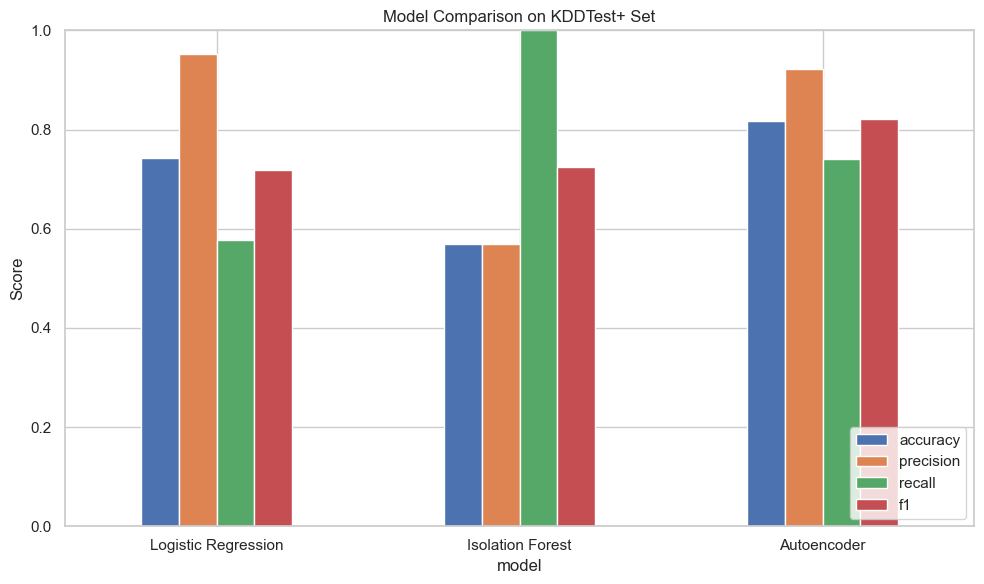

In [9]:
summary_df.plot(kind = "bar", figsize = (10, 6))
plt.title("Model Comparison on KDDTest+ Set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation = 0)
plt.legend(loc = "lower right")
plt.tight_layout()
# Save the figure to the /images folder
plt.savefig("../images/model_comparison_bar_chart.png", dpi=300)
plt.show()

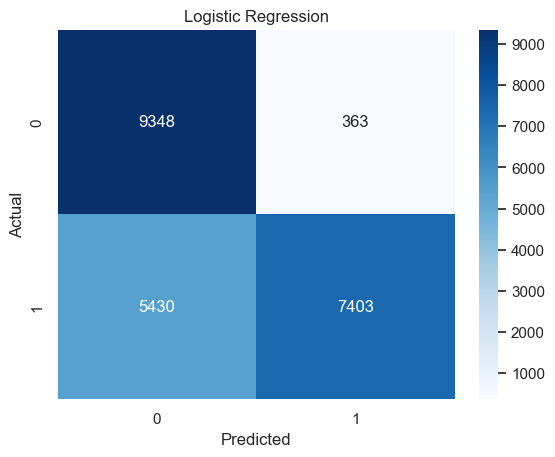

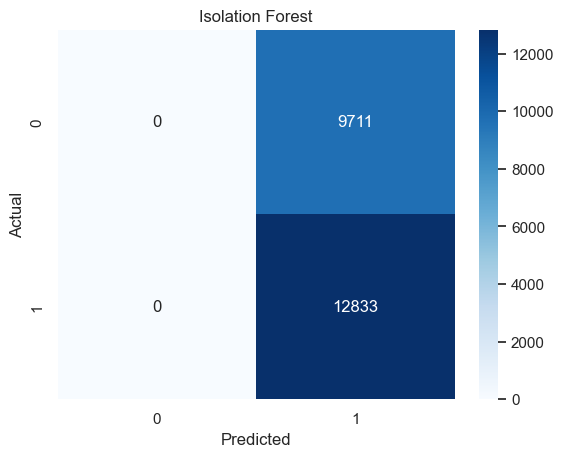

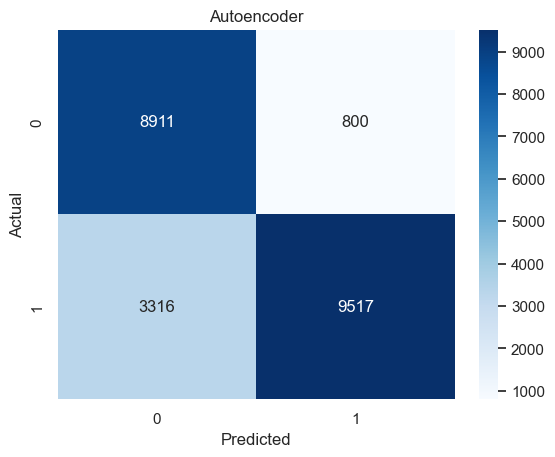

In [8]:
plot_confusion(y_test, y_pred_lr, title = 'Logistic Regression')
plot_confusion(y_test, y_pred_iso, title = 'Isolation Forest')
plot_confusion(y_test, y_pred_ae, title = "Autoencoder")